In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## Data Overview

In [3]:
df = pd.read_csv('../data/laptop_price.csv', encoding='Windows-1252')

In [4]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [6]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
laptop_ID,1303.0,NaN,NaN,NaN,660.155794,381.172104,1.0,331.5,659.0,990.5,1320.0
Company,1303,19,Dell,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1303,618,XPS 13,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TypeName,1303,6,Notebook,727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inches,1303.0,NaN,NaN,NaN,15.017191,1.426304,10.1,14.0,15.6,15.6,18.4
ScreenResolution,1303,40,Full HD 1920x1080,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cpu,1303,118,Intel Core i5 7200U 2.5GHz,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram,1303,9,8GB,619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,1303,39,256GB SSD,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gpu,1303,110,Intel HD Graphics 620,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Feature Engineering

In [7]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [8]:
def cpu_data_extract(data: str) -> tuple:
    cpu_data = data.split()

    cpu_brand = cpu_data[0]
    clock_rate = float(cpu_data[-1].strip('GHz'))

    cpu_model = cpu_data[1]

    for i in cpu_data[2:-1]:
        cpu_model += f' {i}'

    return cpu_brand, cpu_model, clock_rate

In [9]:
df[
    ['Cpu_brand', 'Cpu_model', 'Cpu_clock_rate_(GHz)']
] = df['Cpu'].apply(cpu_data_extract).apply(pd.Series)

In [10]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [11]:
def gpu_data_extract(data: str) -> tuple:
    gpu_data = data.split()

    gpu_brand = gpu_data[0]
    gpu_series = gpu_data[1]

    for i in gpu_data[2:]:
        gpu_series += f' {i}'
    
    if '<U+039C>' in gpu_series:
        gpu_series = 'GeForce GTX 960M'

    return gpu_brand, gpu_series

In [12]:
df[
    ['Gpu_brand', 'Gpu_series']
] = df['Gpu'].apply(gpu_data_extract).apply(pd.Series)

In [13]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [14]:
def resolution_data_extract(screen_resolution: str) -> tuple:
    ips_panel = 0 
    touchscreen = 0
    retina_display = 0
    
    width_resolution, height_resolution = screen_resolution.split(' ')[-1].split('x')
    width_resolution = float(width_resolution)
    height_resolution = float(height_resolution)

    if 'IPS Panel' in screen_resolution:
        ips_panel = 1
    if 'Touchscreen' in screen_resolution:
        touchscreen = 1
    if 'Retina Display' in screen_resolution:
        retina_display = 1
    
    return width_resolution, height_resolution, ips_panel, touchscreen, retina_display

In [15]:
df[
    ['Width_resolution', 'Height_resolution', 'Ips_panel', 'Touchscreen', 'Retina_display']
] = df['ScreenResolution'].apply(resolution_data_extract).apply(pd.Series)

In [16]:
def ppi_calc(width: float, height: float, inch: float) -> float:
    ppi = (np.sqrt(((width ** 2) + (height ** 2)))) / inch
    return ppi

In [17]:
df['PPI'] = np.vectorize(ppi_calc)(df['Width_resolution'], df['Height_resolution'], df['Inches'])

In [18]:
df.loc[
    ~df['Ram'].str.contains('GB', na=False),
    'Ram'
].drop_duplicates()

Series([], Name: Ram, dtype: object)

In [19]:
df['Ram_(GB)'] = df['Ram'].str.extract(r'(\d+)').astype(float)

In [20]:
df.loc[
    ~df['Weight'].str.contains(r'kg', na=False),
    'Weight'
].drop_duplicates()

Series([], Name: Weight, dtype: object)

In [21]:
df['Weight_(kg)'] = df['Weight'].str.extract(r'(\d+\.?\d*)').astype(float)

In [22]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [23]:
def memory_calc(memory: str or bool) -> dict:
    memory_dict = {
        'SSD': 0.0,
        'HDD': 0.0,
        'Flash Storage': 0.0,
        'Hybrid': 0.0,
    }
    
    if memory is None:
        return memory_dict
    
    if 'GB'in memory:
        memory_size, memory_type = memory.split('GB')
        memory_dict[memory_type.strip()] = float(memory_size)
    else:
        memory_size, memory_type = memory.split('TB')
        memory_dict[memory_type.strip()] = float(memory_size) * 1024
        
    return memory_dict

In [24]:
def extract_memory(data: str) -> (float, float, float, float):
    memory_1 = data
    memory_2 = None
    
    if '+' in data:
        memory_1, memory_2 = data.split('+')
    
    
    memory_ssd_1, memory_hdd_1, memory_flash_storage_1, memory_hybrid_1 = memory_calc(memory_1).values()
    
    memory_ssd_2, memory_hdd_2, memory_flash_storage_2, memory_hybrid_2 = memory_calc(memory_2).values()
      
    
    ssd = memory_ssd_1 + memory_ssd_2
    hdd = memory_hdd_1 + memory_hdd_2
    flash_storage = memory_flash_storage_1 + memory_flash_storage_2
    hybrid = memory_hybrid_1 + memory_hybrid_2
    
    return ssd, hdd, flash_storage, hybrid

In [25]:
df[
    ['Memory_SSD_(GB)', 'Memory_HDD_(GB)', 'Memory_Flash_Storage_(GB)', 'Memory_Hybrid_(GB)']
] = df['Memory'].apply(extract_memory).apply(pd.Series)

In [27]:
drop_label = [
    'laptop_ID',
    'Memory',
    'Ram',
    'Weight',
    'ScreenResolution',
    'Cpu',
    'Gpu',
    'Width_resolution',
    'Height_resolution',
]

In [28]:
df.drop(labels=drop_label, axis=1, inplace=True)

In [29]:
df.head()

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
0,Apple,MacBook Pro,Ultrabook,13.3,macOS,1339.69,Intel,Core i5,2.3,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,128.0,0.0,0.0,0.0
1,Apple,Macbook Air,Ultrabook,13.3,macOS,898.94,Intel,Core i5,1.8,Intel,...,0.0,0.0,0.0,127.677940,8.0,1.34,0.0,0.0,128.0,0.0
2,HP,250 G6,Notebook,15.6,No OS,575.00,Intel,Core i5 7200U,2.5,Intel,...,0.0,0.0,0.0,141.211998,8.0,1.86,256.0,0.0,0.0,0.0
3,Apple,MacBook Pro,Ultrabook,15.4,macOS,2537.45,Intel,Core i7,2.7,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,512.0,0.0,0.0,0.0
4,Apple,MacBook Pro,Ultrabook,13.3,macOS,1803.60,Intel,Core i5,3.1,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,256.0,0.0,0.0,0.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company                    1303 non-null   object 
 1   Product                    1303 non-null   object 
 2   TypeName                   1303 non-null   object 
 3   Inches                     1303 non-null   float64
 4   OpSys                      1303 non-null   object 
 5   Price_euros                1303 non-null   float64
 6   Cpu_brand                  1303 non-null   object 
 7   Cpu_model                  1303 non-null   object 
 8   Cpu_clock_rate_(GHz)       1303 non-null   float64
 9   Gpu_brand                  1303 non-null   object 
 10  Gpu_series                 1303 non-null   object 
 11  Ips_panel                  1303 non-null   float64
 12  Touchscreen                1303 non-null   float64
 13  Retina_display             1303 non-null   float

In [31]:
df.duplicated().sum()

np.int64(28)

In [32]:
df[df.duplicated()]

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
1275,Asus,ZenBook UX305CA-UBM1,Ultrabook,13.3,Windows 10,729.00,Intel,Core M 6Y30,0.9,Intel,...,1.0,0.0,0.0,165.632118,8.0,1.20,512.0,0.0,0.0,0.0
1276,Dell,Inspiron 3567,Notebook,15.6,Windows 10,459.00,Intel,Core i3 7100U,2.4,Intel,...,0.0,0.0,0.0,100.454670,6.0,2.30,0.0,1024.0,0.0,0.0
1277,Acer,Aspire ES1-531,Notebook,15.6,Linux,289.00,Intel,Celeron Dual Core N3060,1.6,Intel,...,0.0,0.0,0.0,100.454670,4.0,2.40,0.0,500.0,0.0,0.0
1278,Dell,Inspiron 3552,Notebook,15.6,Windows 10,379.00,Intel,Celeron Dual Core N3050,1.6,Intel,...,0.0,0.0,0.0,100.454670,2.0,2.20,0.0,500.0,0.0,0.0
1279,Lenovo,IdeaPad Y700-15ISK,Notebook,15.6,Windows 10,899.00,Intel,Core i7 6700HQ,2.6,Nvidia,...,1.0,0.0,0.0,141.211998,8.0,2.60,0.0,1024.0,0.0,0.0
1280,HP,Pavilion 15-AW003nv,Notebook,15.6,Windows 10,549.99,AMD,A9-Series 9410,2.9,AMD,...,0.0,0.0,0.0,141.211998,6.0,2.04,0.0,0.0,0.0,1024.0
1281,Dell,Inspiron 3567,Notebook,15.6,Linux,805.99,Intel,Core i7 7500U,2.7,AMD,...,0.0,0.0,0.0,100.454670,8.0,2.30,0.0,1024.0,0.0,0.0
1282,HP,Stream 11-Y000na,Netbook,11.6,Windows 10,209.00,Intel,Celeron Dual Core N3060,1.6,Intel,...,0.0,0.0,0.0,135.094211,2.0,1.17,0.0,0.0,32.0,0.0
1283,Asus,X556UJ-XO044T (i7-6500U/4GB/500GB/GeForce,Notebook,15.6,Windows 10,720.32,Intel,Core i7 6500U,2.5,Nvidia,...,0.0,0.0,0.0,100.454670,4.0,2.20,0.0,500.0,0.0,0.0
1284,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,Windows 10,638.00,Intel,Core i7 6500U,2.5,Intel,...,1.0,1.0,0.0,157.350512,4.0,1.80,128.0,0.0,0.0,0.0


In [33]:
df = df.drop_duplicates(keep='first')

In [34]:
df.duplicated().sum()

np.int64(0)

---
## Missing Value

In [37]:
df.isnull().sum()

Company                      0
Product                      0
TypeName                     0
Inches                       0
OpSys                        0
Price_euros                  0
Cpu_brand                    0
Cpu_model                    0
Cpu_clock_rate_(GHz)         0
Gpu_brand                    0
Gpu_series                   0
Ips_panel                    0
Touchscreen                  0
Retina_display               0
PPI                          0
Ram_(GB)                     0
Weight_(kg)                  0
Memory_SSD_(GB)              0
Memory_HDD_(GB)              0
Memory_Flash_Storage_(GB)    0
Memory_Hybrid_(GB)           0
dtype: int64

**This Dataset is not missing data**

---

## Data Analysis

In [41]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)

In [42]:
skewness

Memory_Hybrid_(GB)           11.469045
Memory_Flash_Storage_(GB)    11.090490
Retina_display                8.496076
Ram_(GB)                      2.698716
PPI                           2.035799
Touchscreen                   1.991028
Price_euros                   1.511147
Memory_SSD_(GB)               1.432869
Weight_(kg)                   1.150804
Ips_panel                     0.981113
Memory_HDD_(GB)               0.902158
Inches                       -0.438622
Cpu_clock_rate_(GHz)         -0.838246
dtype: float64

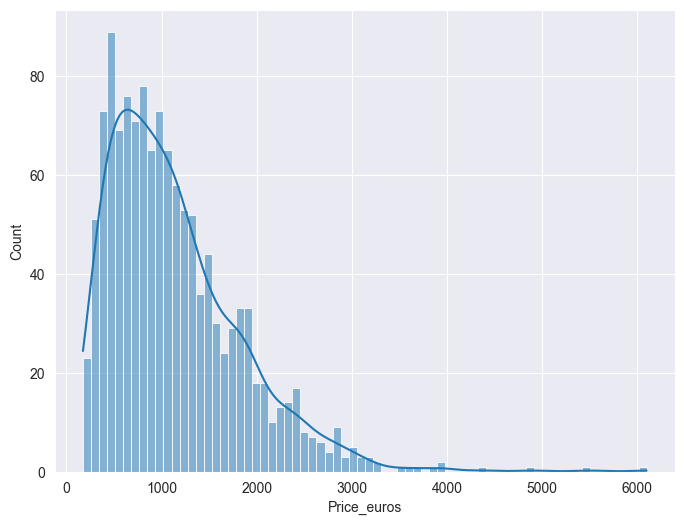

In [324]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Price_euros', data=df, kde=True, bins=70);

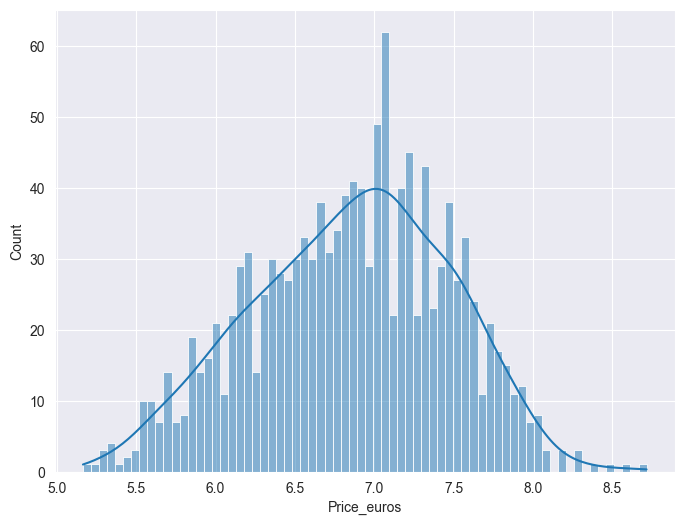

In [325]:
plt.figure(figsize=(8, 6))
sns.histplot(x=np.log1p(df['Price_euros']), kde=True, bins=70);

**The target distribution is not normal and is right skewed. If we look at the target log1p distribution, we will see that our distribution becomes normal, so we conclude that the target needs a log transform.**

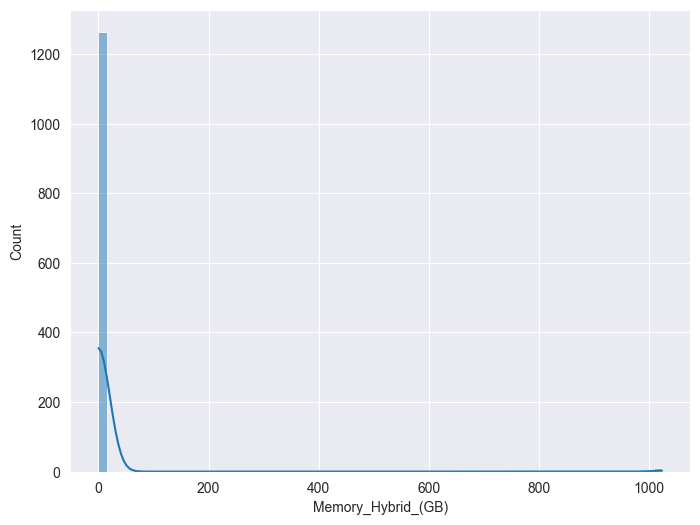

In [53]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Memory_Hybrid_(GB)', data=df, kde=True, bins=70);

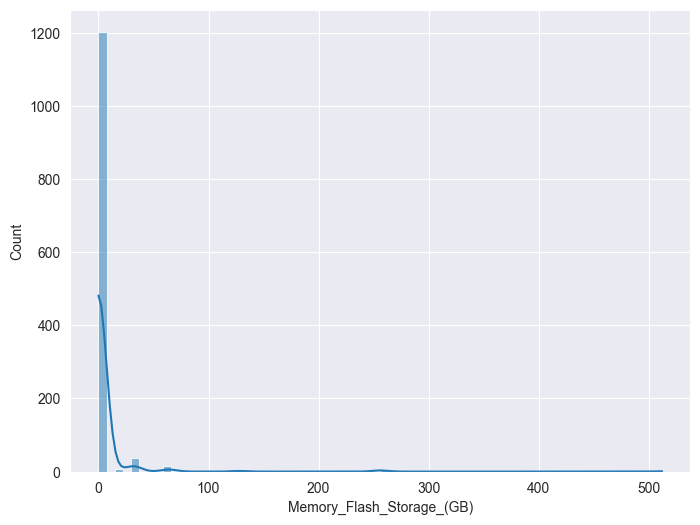

In [56]:
plt.figure(figsize=(8, 6))
sns.histplot(x='Memory_Flash_Storage_(GB)', data=df, kde=True, bins=70);

**Considering the skewness values, we conclude that the input features are not normal and, like the target feature, we must normalize their distribution with a suitable transformer, namely PowerTransformer.**

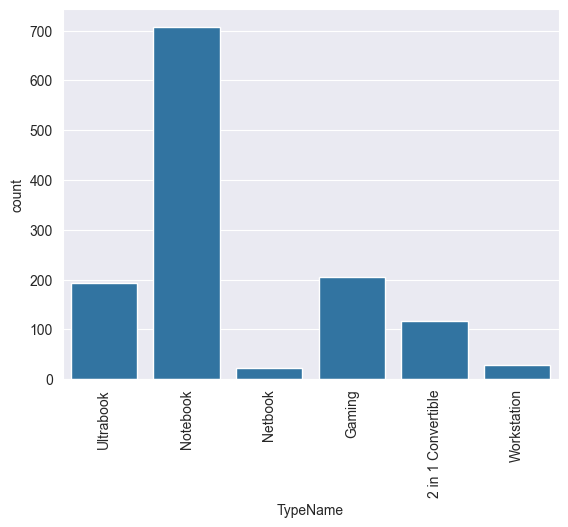

In [60]:
sns.countplot(data=df, x='TypeName')
plt.xticks(rotation=90);

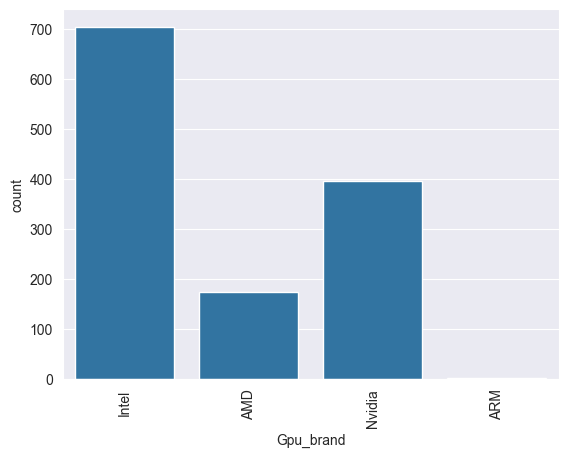

In [61]:
sns.countplot(data=df, x='Gpu_brand')
plt.xticks(rotation=90);

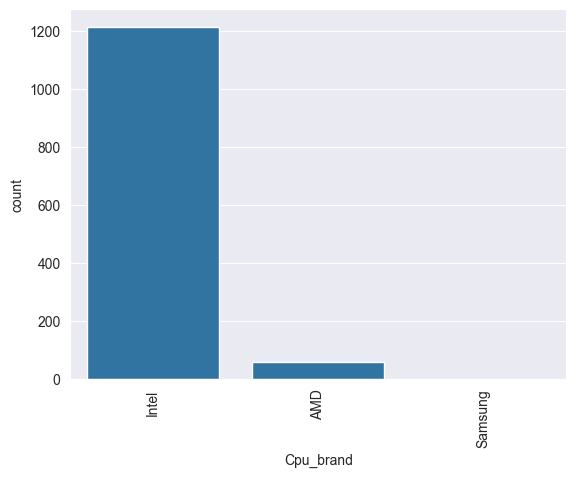

In [62]:
sns.countplot(data=df, x='Cpu_brand')
plt.xticks(rotation=90);

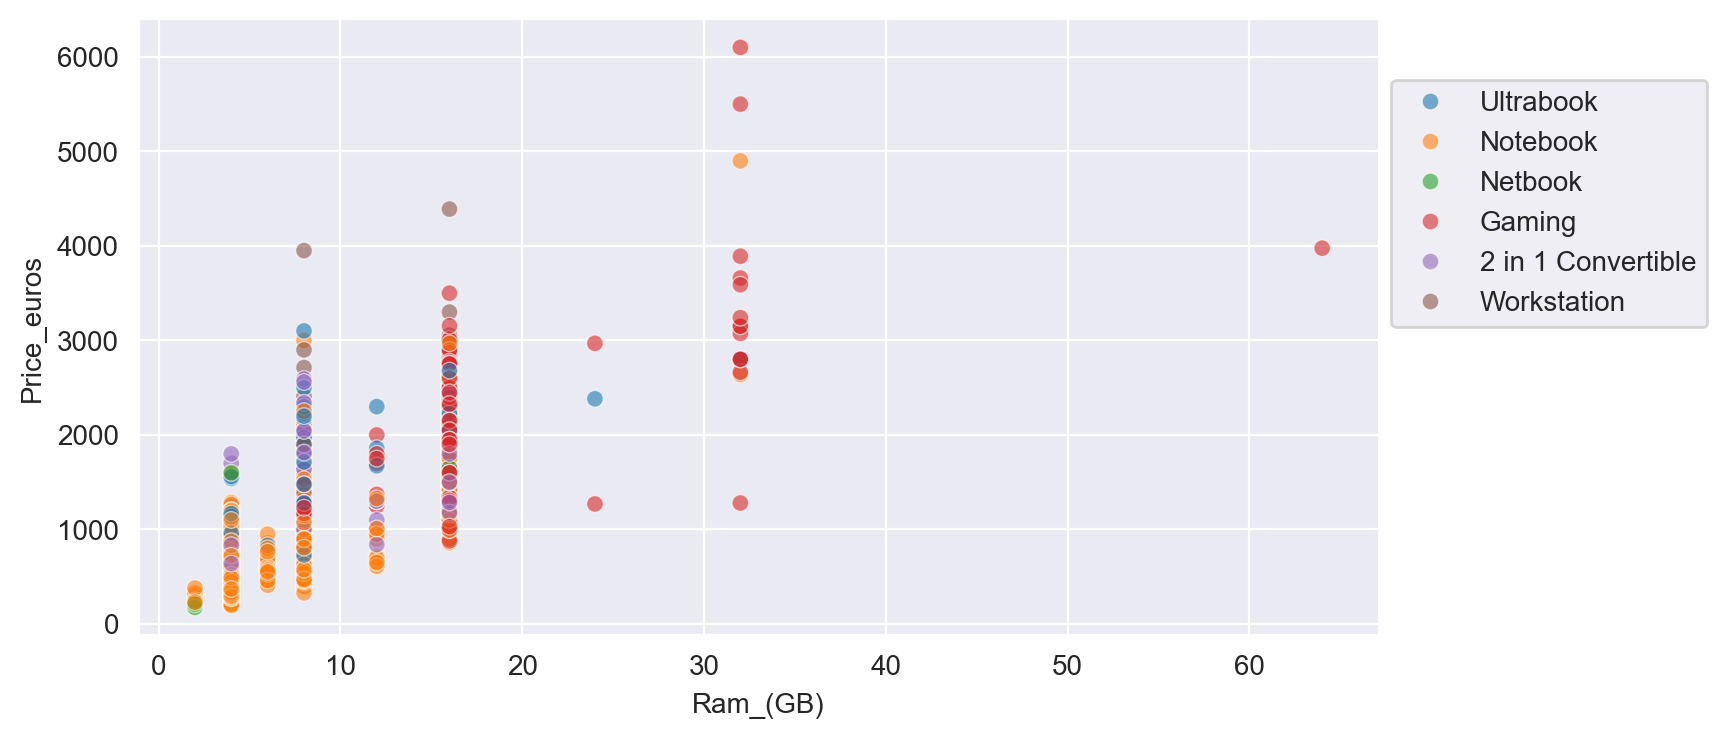

In [63]:
plt.figure(figsize=(8, 4), dpi=200)
sns.scatterplot(x='Ram_(GB)', y='Price_euros', data=df, hue='TypeName', alpha=0.6)
plt.legend(loc=(1.01, 0.5));

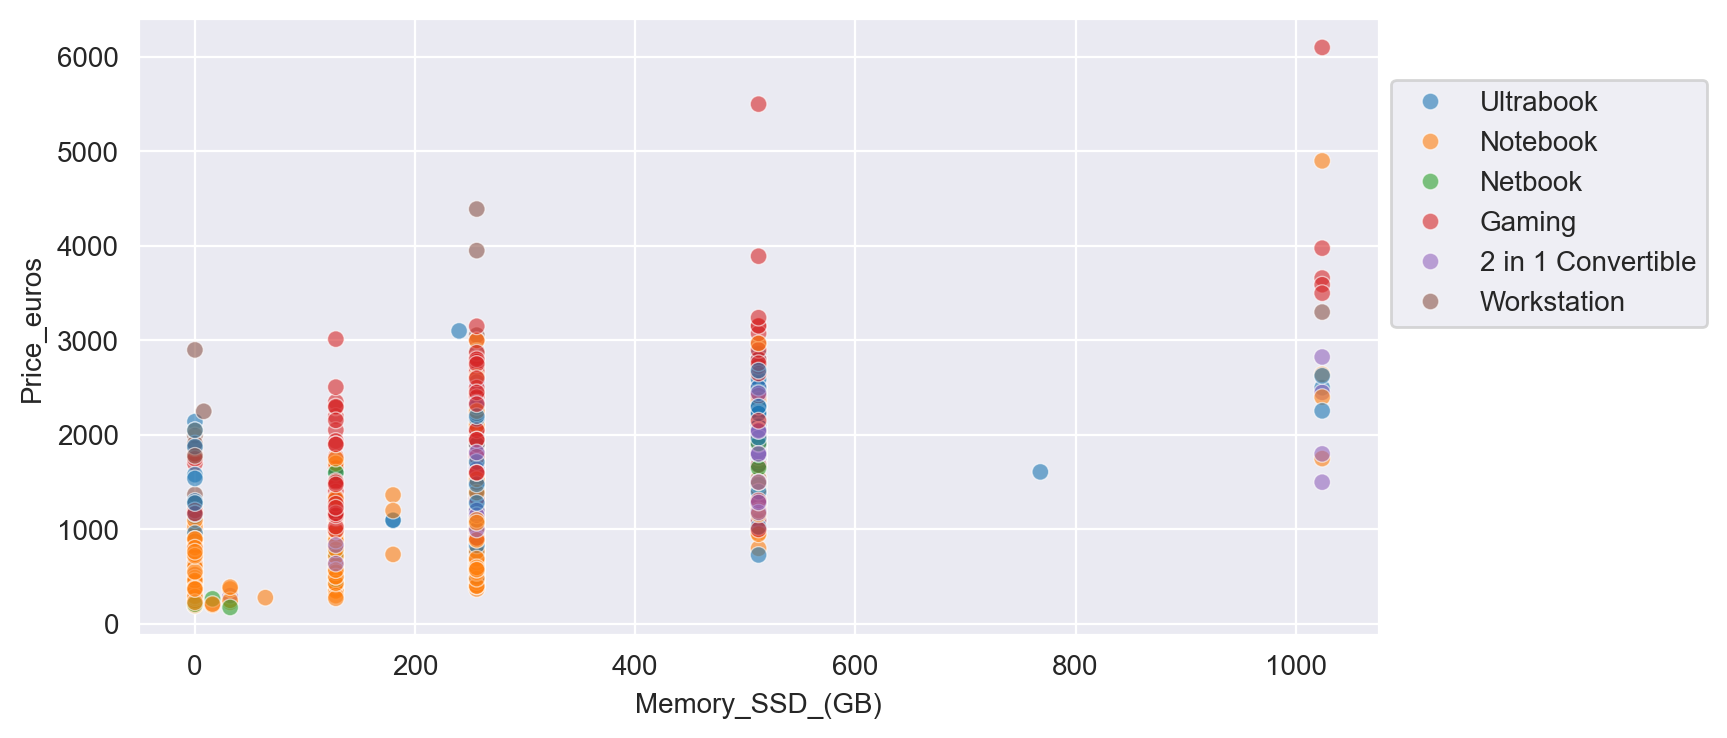

In [64]:
plt.figure(figsize=(8, 4), dpi=200)
sns.scatterplot(x='Memory_SSD_(GB)', y='Price_euros', data=df, hue='TypeName', alpha=0.6)
plt.legend(loc=(1.01, 0.5));

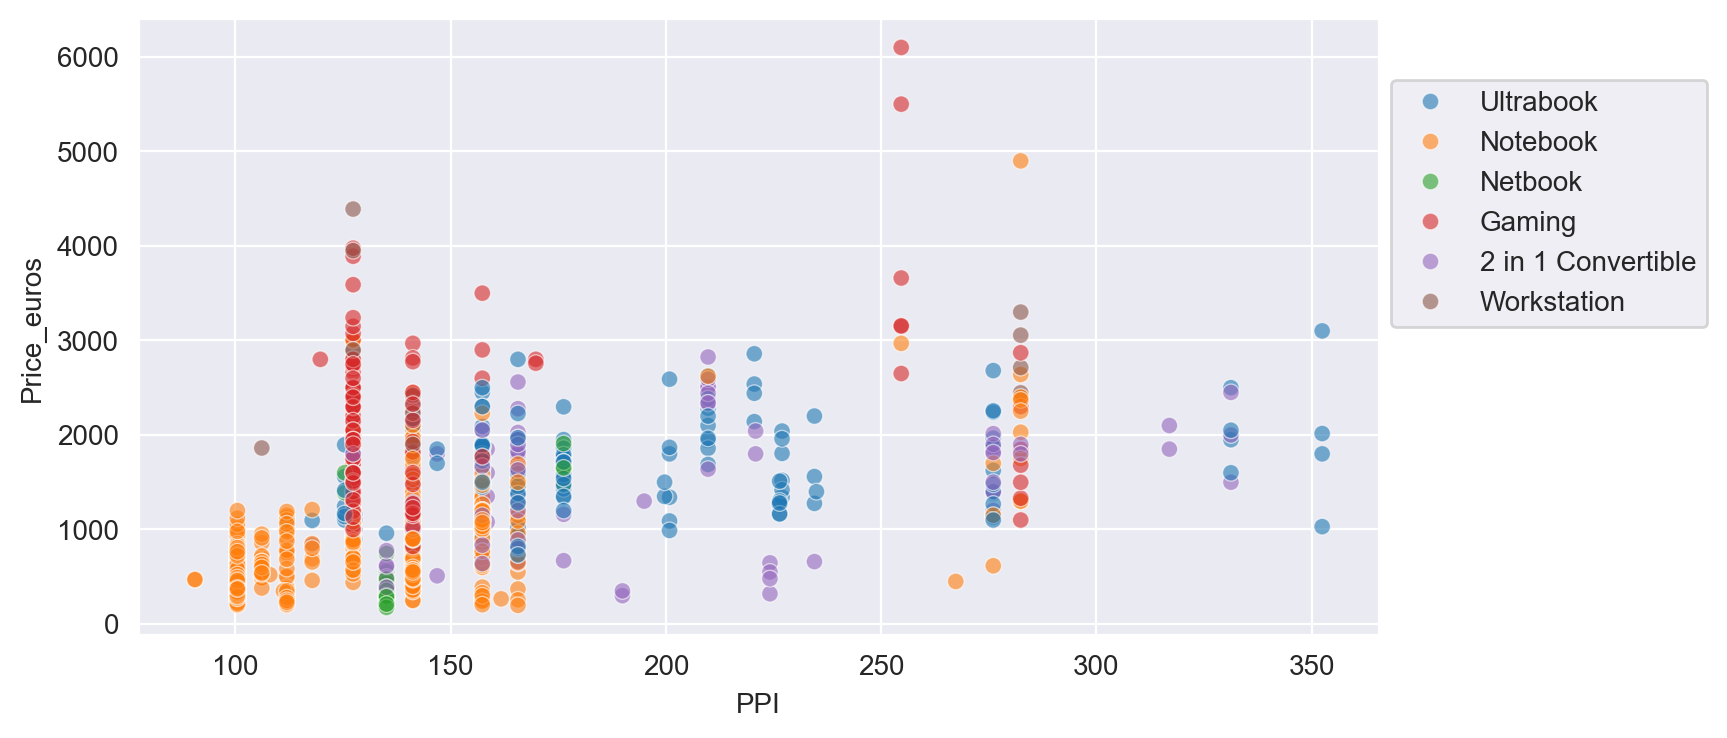

In [65]:
plt.figure(figsize=(8, 4), dpi=200)
sns.scatterplot(x='PPI', y='Price_euros', data=df, hue='TypeName', alpha=0.6)
plt.legend(loc=(1.01, 0.5));

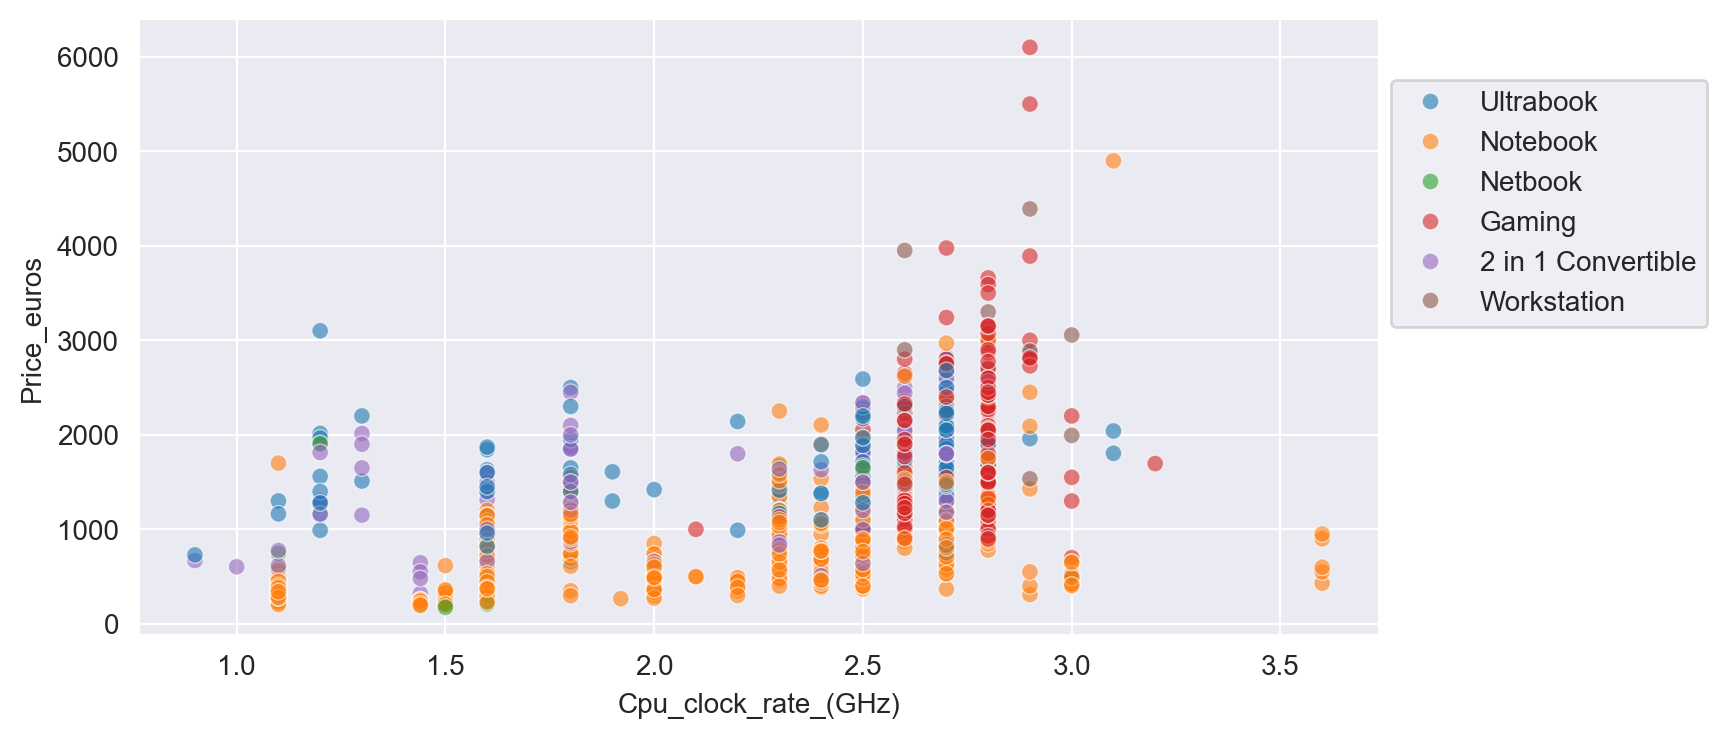

In [66]:
plt.figure(figsize=(8, 4), dpi=200)
sns.scatterplot(x='Cpu_clock_rate_(GHz)', y='Price_euros', data=df, hue='TypeName', alpha=0.6)
plt.legend(loc=(1.01, 0.5));

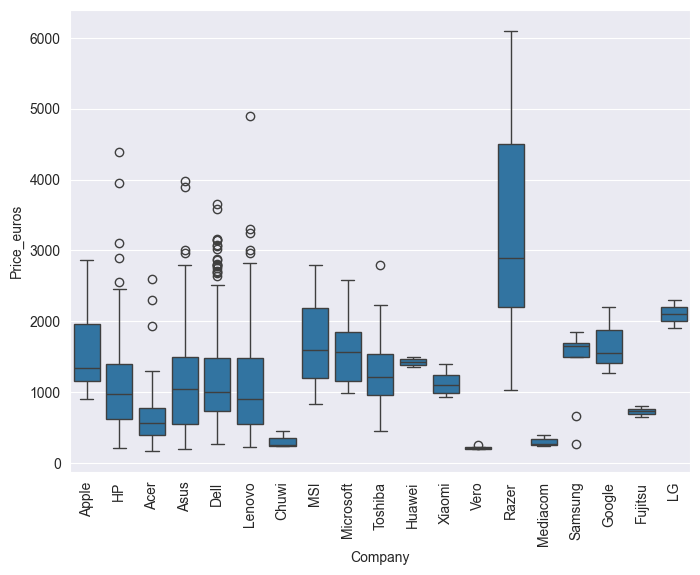

In [67]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Company', y='Price_euros', data=df)
plt.xticks(rotation=90);

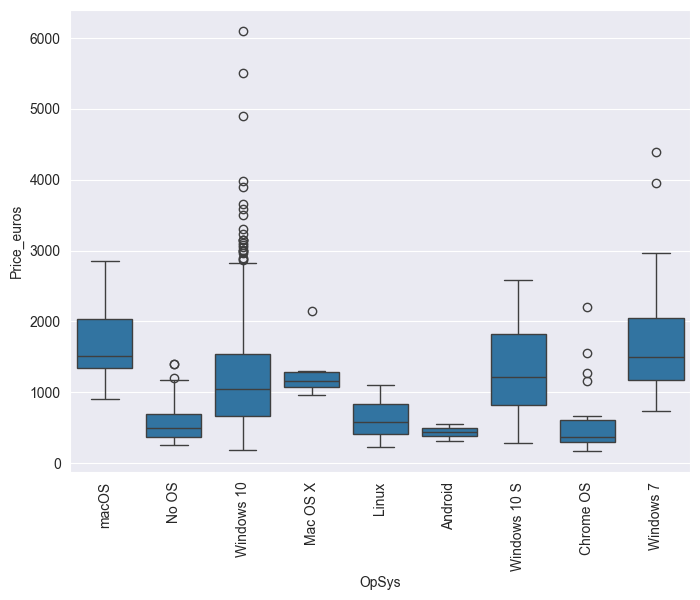

In [68]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='OpSys', y='Price_euros', data=df)
plt.xticks(rotation=90);

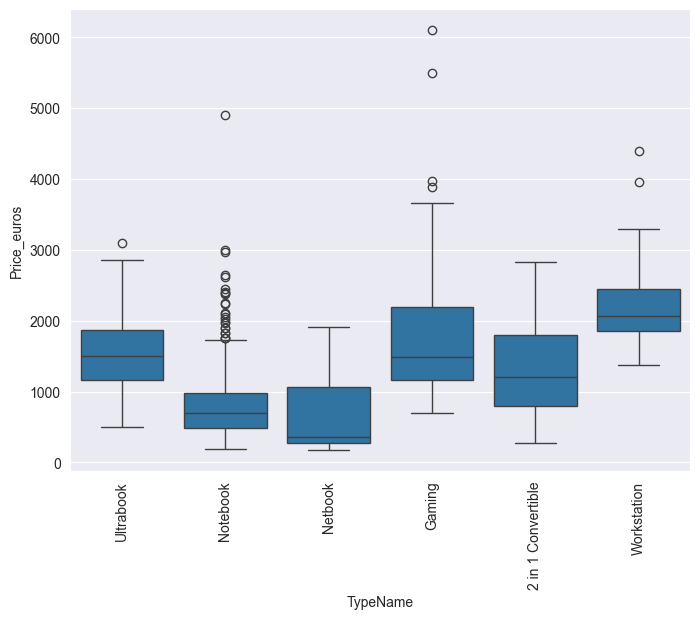

In [69]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='TypeName', y='Price_euros', data=df)
plt.xticks(rotation=90);

---
## Correlation Analysis

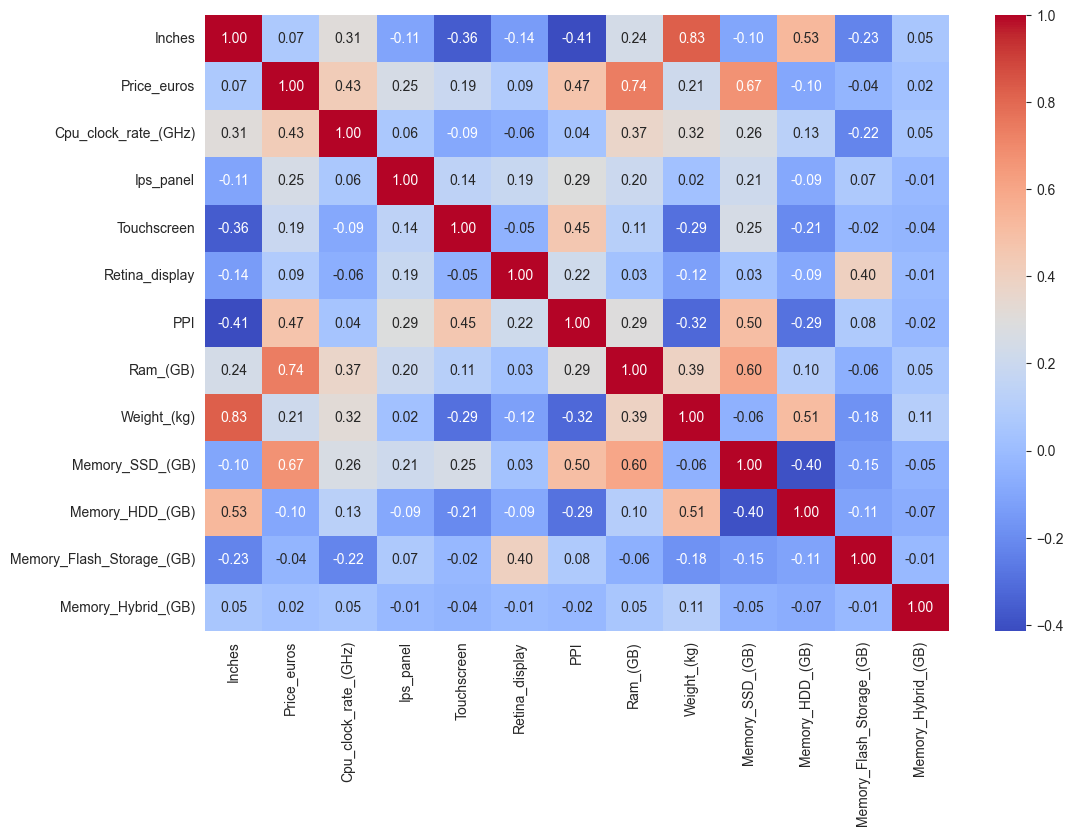

In [70]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
);

In [71]:
df.corr(numeric_only=True)['Price_euros'].sort_values(ascending=False)

Price_euros                  1.000000
Ram_(GB)                     0.740287
Memory_SSD_(GB)              0.670086
PPI                          0.470032
Cpu_clock_rate_(GHz)         0.428847
Ips_panel                    0.250737
Weight_(kg)                  0.211883
Touchscreen                  0.188886
Retina_display               0.086775
Inches                       0.066608
Memory_Hybrid_(GB)           0.022633
Memory_Flash_Storage_(GB)   -0.037031
Memory_HDD_(GB)             -0.096599
Name: Price_euros, dtype: float64

---
## Outlier Analysis

In [72]:
def outliers_calc(dataframe: pd.DataFrame, feature: str) -> pd.Series:
    series = dataframe[feature]

    q_1 = series.quantile(0.25)
    q_3 = series.quantile(0.75)
    
    iqr = q_3 - q_1
    
    lower = q_1 - (1.5 * iqr)
    upper = q_3 + (1.5 * iqr)
    
    return df[(series < lower) | (series > upper)]

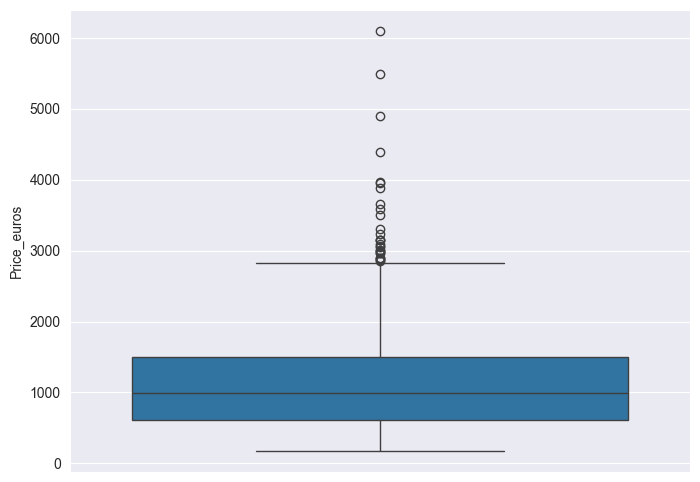

In [73]:
plt.figure(figsize=(8, 6))
sns.boxplot(df['Price_euros']);

In [74]:
price_outlier = outliers_calc(df, 'Price_euros')

In [75]:
price_outlier

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
17,Apple,MacBook Pro,Ultrabook,15.4,macOS,2858.00,Intel,Core i7,2.9,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,512.0,0.0,0.0,0.0
196,Razer,Blade Pro,Gaming,17.3,Windows 10,6099.00,Intel,Core i7 7820HK,2.9,Nvidia,...,0.0,1.0,0.0,254.671349,32.0,3.49,1024.0,0.0,0.0,0.0
204,Dell,Precision 7520,Workstation,15.6,Windows 10,3055.00,Intel,Xeon E3-1505M V6,3.0,Nvidia,...,0.0,0.0,0.0,282.423996,16.0,2.80,256.0,1024.0,0.0,0.0
238,Asus,ROG G703VI-E5062T,Gaming,17.3,Windows 10,3890.00,Intel,Core i7 7820HK,2.9,Nvidia,...,0.0,0.0,0.0,127.335675,32.0,4.70,512.0,1024.0,0.0,0.0
247,Asus,Rog G701VIK-BA060T,Gaming,17.3,Windows 10,2999.00,Intel,Core i7 7820HK,2.9,Nvidia,...,0.0,0.0,0.0,127.335675,16.0,3.60,256.0,0.0,0.0,0.0
297,Dell,Precision 7720,Workstation,17.3,Windows 10,2884.86,Intel,Core i7 7820HQ,2.9,Nvidia,...,0.0,0.0,0.0,127.335675,16.0,3.42,256.0,0.0,0.0,0.0
517,Asus,ROG Zephyrus,Gaming,15.6,Windows 10,2968.00,Intel,Core i7 7700HQ,2.8,Nvidia,...,0.0,0.0,0.0,141.211998,24.0,2.24,512.0,0.0,0.0,0.0
530,Dell,Alienware 17,Gaming,17.3,Windows 10,3012.77,Intel,Core i7 7700HQ,2.8,Nvidia,...,1.0,0.0,0.0,127.335675,16.0,4.42,128.0,1024.0,0.0,0.0
563,Lenovo,Thinkpad P71,Notebook,17.3,Windows 10,2999.00,Intel,Core i7 7700HQ,2.8,Nvidia,...,1.0,0.0,0.0,127.335675,8.0,3.40,256.0,0.0,0.0,0.0
610,Lenovo,Thinkpad P51,Notebook,15.6,Windows 10,4899.00,Intel,Xeon E3-1535M v6,3.1,Nvidia,...,1.0,0.0,0.0,282.423996,32.0,2.50,1024.0,0.0,0.0,0.0


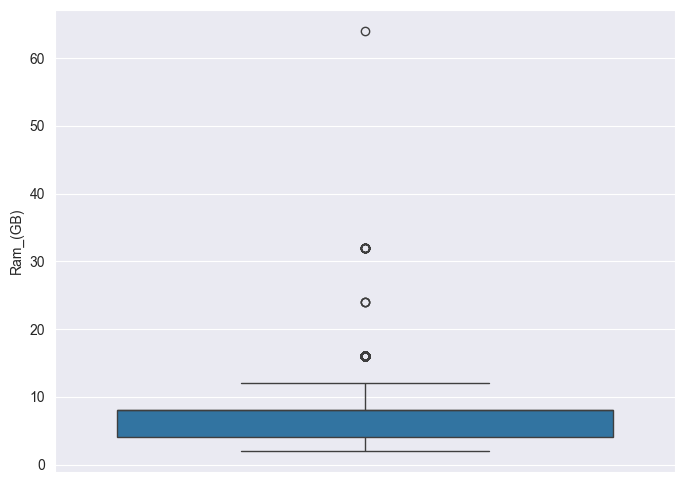

In [76]:
plt.figure(figsize=(8, 6))
sns.boxplot(df['Ram_(GB)']);

In [77]:
ram_outlier = outliers_calc(df, 'Ram_(GB)')

In [78]:
ram_outlier

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
3,Apple,MacBook Pro,Ultrabook,15.4,macOS,2537.45,Intel,Core i7,2.7,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,512.0,0.0,0.0,0.0
6,Apple,MacBook Pro,Ultrabook,15.4,Mac OS X,2139.97,Intel,Core i7,2.2,Intel,...,1.0,0.0,1.0,220.534624,16.0,2.04,0.0,0.0,256.0,0.0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Windows 10,1495.00,Intel,Core i7 8550U,1.8,Nvidia,...,0.0,0.0,0.0,157.350512,16.0,1.30,512.0,0.0,0.0,0.0
12,Apple,MacBook Pro,Ultrabook,15.4,macOS,2439.97,Intel,Core i7,2.8,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,256.0,0.0,0.0,0.0
17,Apple,MacBook Pro,Ultrabook,15.4,macOS,2858.00,Intel,Core i7,2.9,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,512.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,Dell,Inspiron 7779,2 in 1 Convertible,17.3,Windows 10,1799.00,Intel,Core i7 7500U,2.7,Nvidia,...,0.0,1.0,0.0,127.335675,16.0,2.77,512.0,0.0,0.0,0.0
1245,Asus,Rog GL553VE-FY052T,Gaming,15.6,Windows 10,1600.00,Intel,Core i7 7700HQ,2.8,Nvidia,...,1.0,0.0,0.0,141.211998,16.0,2.50,256.0,1024.0,0.0,0.0
1247,Asus,Rog GL502VS,Gaming,15.6,Windows 10,2325.00,Intel,Core i7 6700HQ,2.6,Nvidia,...,1.0,0.0,0.0,141.211998,16.0,2.34,256.0,1024.0,0.0,0.0
1256,Asus,Rog G752VT-GC073T,Gaming,17.3,Windows 10,1900.00,Intel,Core i7 6700HQ,2.6,Nvidia,...,1.0,0.0,0.0,127.335675,16.0,4.00,128.0,1024.0,0.0,0.0


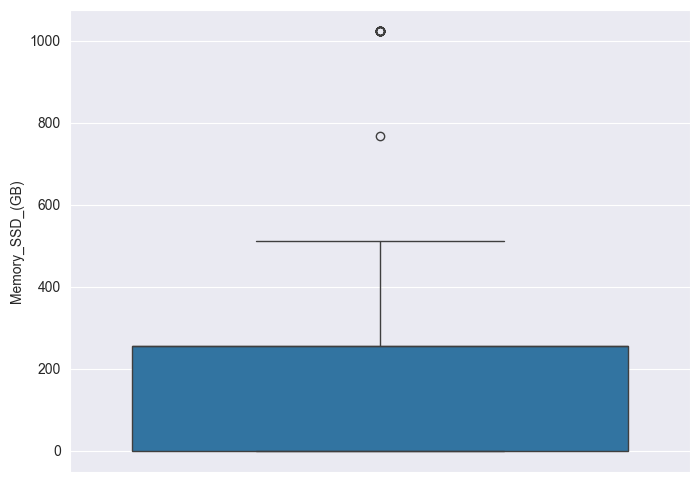

In [79]:
plt.figure(figsize=(8, 6))
sns.boxplot(df['Memory_SSD_(GB)']);

In [80]:
memory_ssd_outlier = outliers_calc(df, 'Memory_SSD_(GB)')

In [81]:
memory_ssd_outlier

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
190,Lenovo,Thinkpad Yoga,2 in 1 Convertible,14.0,Windows 10,2824.00,Intel,Core i7 7500U,2.7,Intel,...,0.0,1.0,0.0,209.800683,16.0,1.42,1024.0,0.0,0.0,0.0
196,Razer,Blade Pro,Gaming,17.3,Windows 10,6099.00,Intel,Core i7 7820HK,2.9,Nvidia,...,0.0,1.0,0.0,254.671349,32.0,3.49,1024.0,0.0,0.0,0.0
266,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Windows 10,1499.00,Intel,Core i7 8550U,1.8,Intel,...,0.0,1.0,0.0,165.632118,8.0,1.10,1024.0,0.0,0.0,0.0
311,Dell,XPS 13,Ultrabook,13.3,Windows 10,2499.00,Intel,Core i7 8550U,1.8,Intel,...,1.0,1.0,0.0,331.264236,16.0,1.21,1024.0,0.0,0.0,0.0
316,HP,Spectre x360,2 in 1 Convertible,13.3,Windows 10,2449.00,Intel,Core i7 8550U,1.8,Intel,...,1.0,1.0,0.0,331.264236,16.0,1.29,1024.0,0.0,0.0,0.0
329,Dell,XPS 15,Notebook,15.6,Windows 10,2639.00,Intel,Core i7 7700HQ,2.8,Nvidia,...,0.0,1.0,0.0,282.423996,32.0,2.06,1024.0,0.0,0.0,0.0
347,Dell,Latitude 5590,Ultrabook,15.6,Windows 10,1607.96,Intel,Core i7 8650U,1.9,Intel,...,0.0,0.0,0.0,141.211998,16.0,1.88,768.0,0.0,0.0,0.0
399,Lenovo,Thinkpad X1,Ultrabook,14.0,Windows 10,2625.00,Intel,Core i7 7500U,2.7,Intel,...,1.0,0.0,0.0,209.800683,16.0,1.13,1024.0,0.0,0.0,0.0
497,HP,EliteBook 840,Notebook,14.0,Windows 10,1749.00,Intel,Core i7 7600U,2.8,Intel,...,0.0,0.0,0.0,157.350512,8.0,1.48,1024.0,0.0,0.0,0.0
610,Lenovo,Thinkpad P51,Notebook,15.6,Windows 10,4899.00,Intel,Xeon E3-1535M v6,3.1,Nvidia,...,1.0,0.0,0.0,282.423996,32.0,2.50,1024.0,0.0,0.0,0.0


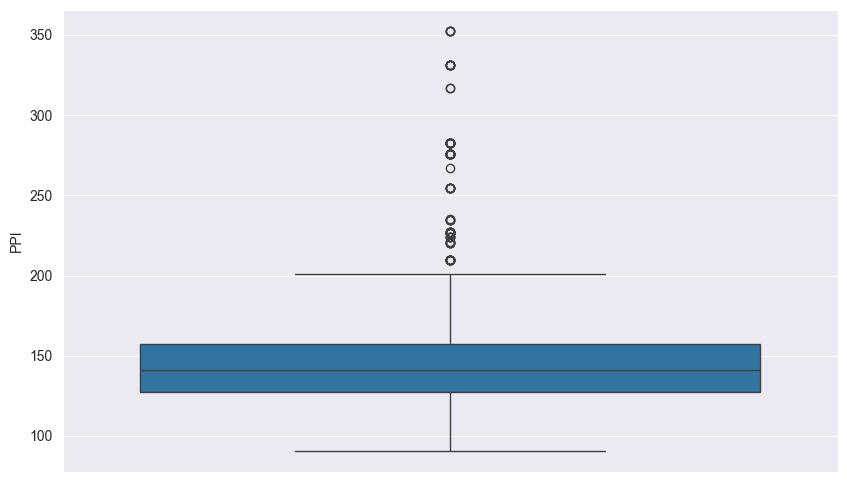

In [82]:
plt.figure(figsize=(10, 6))
sns.boxplot(df['PPI']);

In [83]:
ppi_outlier = outliers_calc(df, 'PPI')

In [84]:
ppi_outlier

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
0,Apple,MacBook Pro,Ultrabook,13.3,macOS,1339.69,Intel,Core i5,2.3,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,128.0,0.0,0.0,0.0
3,Apple,MacBook Pro,Ultrabook,15.4,macOS,2537.45,Intel,Core i7,2.7,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,512.0,0.0,0.0,0.0
4,Apple,MacBook Pro,Ultrabook,13.3,macOS,1803.60,Intel,Core i5,3.1,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,256.0,0.0,0.0,0.0
6,Apple,MacBook Pro,Ultrabook,15.4,Mac OS X,2139.97,Intel,Core i7,2.2,Intel,...,1.0,0.0,1.0,220.534624,16.0,2.04,0.0,0.0,256.0,0.0
12,Apple,MacBook Pro,Ultrabook,15.4,macOS,2439.97,Intel,Core i7,2.8,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,256.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,Apple,"MacBook 12""",Ultrabook,12.0,Mac OS X,1279.00,Intel,Core M,1.2,Intel,...,1.0,0.0,1.0,226.415547,8.0,0.92,0.0,0.0,512.0,0.0
1226,Dell,XPS 13,Ultrabook,13.3,Windows 10,1477.00,Intel,Core i7 7500U,2.7,Intel,...,0.0,1.0,0.0,276.053530,8.0,1.29,256.0,0.0,0.0,0.0
1236,HP,EliteBook 840,Ultrabook,14.0,Windows 7,2198.19,Intel,Core i7 6500U,2.5,Intel,...,0.0,0.0,0.0,209.800683,8.0,1.54,256.0,0.0,0.0,0.0
1249,Dell,XPS 13,2 in 1 Convertible,13.3,Windows 10,1813.00,Intel,Core i5 7Y54,1.2,Intel,...,0.0,1.0,0.0,276.053530,8.0,1.24,256.0,0.0,0.0,0.0


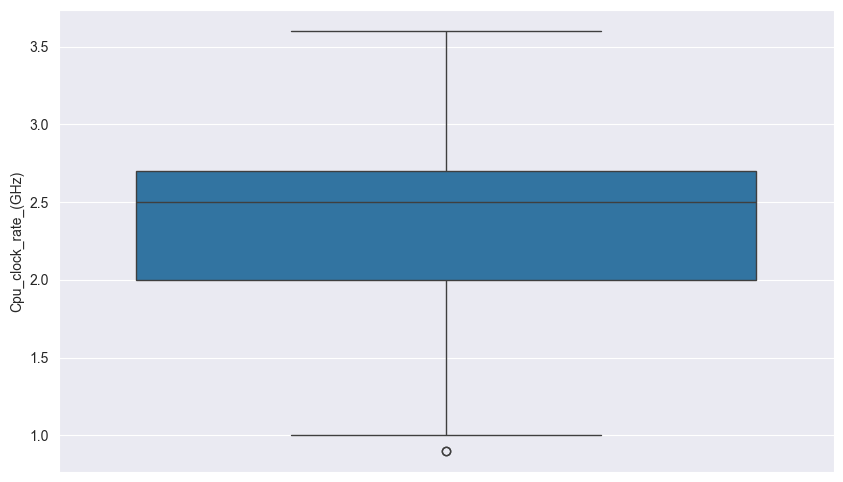

In [85]:
plt.figure(figsize=(10, 6))
sns.boxplot(df['Cpu_clock_rate_(GHz)']);

In [86]:
cpu_clock_outlier = outliers_calc(df, 'Cpu_clock_rate_(GHz)')

In [87]:
cpu_clock_outlier

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
697,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Chrome OS,669.0,Intel,Core M M3-6Y30,0.9,Intel,...,0.0,1.0,0.0,176.232574,4.0,1.2,0.0,0.0,64.0,0.0
1261,Asus,ZenBook UX305CA-UBM1,Ultrabook,13.3,Windows 10,729.0,Intel,Core M 6Y30,0.9,Intel,...,1.0,0.0,0.0,165.632118,8.0,1.2,512.0,0.0,0.0,0.0


**When reviewing the outliers, I realized that this data is not outliers. For example, RAM above 16 GB was marked as outliers. However, these are not outliers, so I do not delete this data**

In [88]:
df.to_csv('../data/laptop_processed.csv', index=False)